## PCA vs Kernel PCA on Synthetic Data

This notebook compares PCA and Kernel PCA on four synthetic datasets, building from interactive intuition to classification and clustering.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


### Helper Functions


In [2]:
def center_data(X):
    """Subtract the mean from each feature."""
    return X - X.mean(axis=0)

def cov_matrix(X):
    """Compute covariance matrix."""
    X = np.asarray(X, dtype=float)
    Xc = X - X.mean(axis=0)
    return (Xc.T @ Xc) / (len(X) - 1)

def pca_project(X, n_components=2):
    """PCA: eigendecomposition of covariance matrix, project to top components."""
    Xc = center_data(X)
    S = (Xc.T @ Xc) / (len(Xc) - 1)
    eigvals, eigvecs = np.linalg.eigh(S)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    W = eigvecs[:, :n_components]
    Z = Xc @ W
    pos = eigvals > 1e-10
    ratios = eigvals[pos] / eigvals[pos].sum()
    return Z, eigvecs, eigvals, ratios

def poly_kernel(X, Y, degree=3, coef0=1.0):
    """Polynomial kernel: K(x,y) = (x^T y + c)^d."""
    return (np.asarray(X) @ np.asarray(Y).T + coef0) ** degree

def gaussian_kernel(X, Y, sigma=1.0):
    """Gaussian kernel: K(x,y) = exp(-||x-y||^2 / 2*sigma^2)."""
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)
    X_sq = np.sum(X**2, axis=1).reshape(-1, 1)
    Y_sq = np.sum(Y**2, axis=1).reshape(1, -1)
    dist_sq = np.maximum(X_sq + Y_sq - 2 * X @ Y.T, 0.0)  # clamp tiny negatives from roundoff
    return np.exp(-dist_sq / (2 * sigma**2))

def center_kernel(K):
    """Center kernel matrix in feature space."""
    n = K.shape[0]
    one_n = np.ones((n, n)) / n
    return K - one_n @ K - K @ one_n + one_n @ K @ one_n

def kpca_project(X, kernel_func, n_components=2, **kernel_params):
    """Kernel PCA: build kernel matrix, center, eigendecompose, project."""
    K = kernel_func(X, X, **kernel_params)
    Kc = center_kernel(K)
    eigvals, eigvecs = np.linalg.eigh(Kc)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    # Keep only numerically positive eigenvalues, then take the top components.
    # (Slicing before filtering could silently divide by the 1e-10 floor and
    # produce garbage components if n_components exceeded the positive count.)
    pos = eigvals > 1e-10
    eigvals_pos = eigvals[pos]
    eigvecs_pos = eigvecs[:, pos]
    n_components = min(n_components, eigvecs_pos.shape[1])
    alpha = eigvecs_pos[:, :n_components] / np.sqrt(eigvals_pos[:n_components])
    Z = Kc @ alpha
    ratios = eigvals_pos / eigvals_pos.sum()
    return Z, eigvals, ratios


In [3]:
def plot_pca_vectors(X, eigvecs, eigvals, title="PCA"):
    """Plot data with principal component directions."""
    mu = X.mean(axis=0)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(X[:, 0], X[:, 1], s=30, alpha=0.6)
    
    data_range = max(X[:, 0].max() - X[:, 0].min(), X[:, 1].max() - X[:, 1].min())
    
    for i, (vec, val) in enumerate(zip(eigvecs.T[:2], eigvals[:2])):
        ratio = val / eigvals[0]
        scale = data_range * 0.35 * ratio
        color = ['red', 'blue'][i]
        end = mu + vec * scale
        ax.annotate('', xy=end, xytext=mu,
                     arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
        ax.text(end[0] + data_range*0.03, end[1] + data_range*0.03,
                f"PC{i+1} ({val:.2f})", color=color, fontsize=10, fontweight='bold')
    
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=13)
    ax.grid(True, alpha=0.3)
    return fig, ax

def plot_comparison(X, Z_pca, Z_kpca, pca_ratios, kpca_ratios, title="", colors=None):
    """Side-by-side: original data, PCA 1D projection, KPCA 1D projection."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    c = colors if colors is not None else 'steelblue'
    
    # Original data
    axes[0].scatter(X[:, 0], X[:, 1], c=c, s=30, alpha=0.7, edgecolors='white', linewidths=0.3)
    axes[0].set_title("Original Data", fontsize=12)
    axes[0].grid(True, alpha=0.3)
    
    # PCA: plot as 1D strip (index vs PC1) when PC1 dominates, else 2D scatter
    if pca_ratios[0] > 0.9:
        # PC1 dominates: show 1D projection
        order = np.argsort(Z_pca[:, 0])
        axes[1].scatter(Z_pca[order, 0], np.zeros_like(Z_pca[:, 0]),
                        c=np.array(c)[order] if isinstance(c, np.ndarray) else c,
                        s=40, alpha=0.7, edgecolors='white', linewidths=0.3)
        axes[1].set_xlabel(f"PC1 ({pca_ratios[0]*100:.1f}%)", fontsize=11)
        axes[1].set_yticks([])
        axes[1].set_ylim(-1, 1)
    else:
        axes[1].scatter(Z_pca[:, 0], Z_pca[:, 1], c=c, s=30, alpha=0.7,
                        edgecolors='white', linewidths=0.3)
        axes[1].set_xlabel(f"PC1 ({pca_ratios[0]*100:.1f}%)", fontsize=11)
        axes[1].set_ylabel(f"PC2 ({pca_ratios[1]*100:.1f}%)", fontsize=11)
    axes[1].axhline(0, c='gray', lw=0.5); axes[1].axvline(0, c='gray', lw=0.5)
    axes[1].set_title("PCA Projection", fontsize=12)
    axes[1].grid(True, alpha=0.3)
    
    # KPCA
    if kpca_ratios[0] > 0.9:
        order = np.argsort(Z_kpca[:, 0])
        axes[2].scatter(Z_kpca[order, 0], np.zeros_like(Z_kpca[:, 0]),
                        c=np.array(c)[order] if isinstance(c, np.ndarray) else c,
                        s=40, alpha=0.7, edgecolors='white', linewidths=0.3)
        axes[2].set_xlabel(f"KPC1 ({kpca_ratios[0]*100:.1f}%)", fontsize=11)
        axes[2].set_yticks([])
        axes[2].set_ylim(-1, 1)
    else:
        axes[2].scatter(Z_kpca[:, 0], Z_kpca[:, 1], c=c, s=30, alpha=0.7,
                        edgecolors='white', linewidths=0.3)
        axes[2].set_xlabel(f"KPC1 ({kpca_ratios[0]*100:.1f}%)", fontsize=11)
        axes[2].set_ylabel(f"KPC2 ({kpca_ratios[1]*100:.1f}%)", fontsize=11)
    axes[2].axhline(0, c='gray', lw=0.5); axes[2].axvline(0, c='gray', lw=0.5)
    axes[2].set_title("Kernel PCA Projection", fontsize=12)
    axes[2].grid(True, alpha=0.3)
    
    fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


---
## Section 1 — Interactive PCA: Understanding Max-Variance Projection

Drag the slider to rotate the projection axis. The left panel shows original points and their projections onto the axis (orange). The right panels show the 1D distribution and variance at each angle. **PCA picks the angle that maximises variance.**

In [4]:
import altair as alt
import pandas as pd

alt.data_transformers.disable_max_rows()

# Generate data
np.random.seed(0)
X_demo = np.random.uniform(0, 10, size=(30, 2))
X_demo[:, 1] = 0.5 * X_demo[:, 0] + np.random.uniform(-0.5, 0.5, 30)
X_c = X_demo - X_demo.mean(axis=0)
mu = X_demo.mean(axis=0)

# PCA solution
S = cov_matrix(X_demo)
eigvals, eigvecs = np.linalg.eigh(S)
idx_sort = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx_sort]; eigvecs = eigvecs[:, idx_sort]
pca_angle = int(np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0])) % 180)

# PCA projection (fixed reference)
w_pca = np.array([np.cos(np.radians(pca_angle)), np.sin(np.radians(pca_angle))])
pca_proj_vals = X_c @ w_pca

# Precompute for all angles
rows_data = []
rows_var = []
rows_line = []

for angle in range(0, 180):
    rad = np.radians(angle)
    w = np.array([np.cos(rad), np.sin(rad)])
    proj_vals = X_c @ w
    proj_pts = mu + np.outer(proj_vals, w)
    var = float(np.var(proj_vals))

    for j in range(len(X_demo)):
        rows_data.append({
            'angle': angle,
            'x_orig': float(X_demo[j, 0]), 'y_orig': float(X_demo[j, 1]),
            'x_proj': float(proj_pts[j, 0]), 'y_proj': float(proj_pts[j, 1]),
            'proj_val': float(proj_vals[j]),
            'pca_proj_val': float(pca_proj_vals[j]),
        })
    rows_var.append({'angle': angle, 'variance': var})
    for t in [-15, 15]:
        rows_line.append({
            'angle': angle,
            'x_line': float(mu[0] + t * w[0]),
            'y_line': float(mu[1] + t * w[1])
        })

# Duplicate 0 as 180
for r in [r.copy() for r in rows_data if r['angle'] == 0]:
    r['angle'] = 180; rows_data.append(r)
for r in [r.copy() for r in rows_var if r['angle'] == 0]:
    r['angle'] = 180; rows_var.append(r)
for r in [r.copy() for r in rows_line if r['angle'] == 0]:
    r['angle'] = 180; rows_line.append(r)

df_data = pd.DataFrame(rows_data)
df_var = pd.DataFrame(rows_var)
df_line = pd.DataFrame(rows_line)

# Slider
slider = alt.binding_range(min=0, max=180, step=1, name='Projection Angle (°): ')
sel = alt.selection_point(fields=['angle'], bind=slider, value=pca_angle)

# --- Left: data + projection ---
original = alt.Chart(df_data).transform_filter(sel).mark_circle(size=60, opacity=0.7).encode(
    x=alt.X('x_orig:Q', title='x\u2081', scale=alt.Scale(domain=[-2, 12])),
    y=alt.Y('y_orig:Q', title='x\u2082', scale=alt.Scale(domain=[-3, 7])),
    color=alt.value('steelblue')
)
projected = alt.Chart(df_data).transform_filter(sel).mark_circle(size=50, opacity=0.8).encode(
    x='x_proj:Q', y='y_proj:Q', color=alt.value('tomato')
)
drop = alt.Chart(df_data).transform_filter(sel).mark_rule(strokeWidth=0.8, opacity=0.3).encode(
    x='x_orig:Q', y='y_orig:Q', x2='x_proj:Q', y2='y_proj:Q', color=alt.value('gray')
)
proj_line = alt.Chart(df_line).transform_filter(sel).mark_line(
    strokeWidth=2.5, opacity=0.8, clip=True
).encode(x='x_line:Q', y='y_line:Q', color=alt.value('red'))

left = (original + projected + drop + proj_line).add_params(sel).properties(
    width=400, height=390, title='Drag the slider to rotate projection direction'
)

# --- Top right: 1D strip, same row, PCA=red, current=blue ---
strip_current = alt.Chart(df_data).transform_filter(sel).mark_circle(size=55, opacity=0.8).encode(
    x=alt.X('proj_val:Q', title='Projected value', scale=alt.Scale(domain=[-6, 6])),
    y=alt.value(50),
    color=alt.value('steelblue')
)
strip_pca = alt.Chart(df_data).transform_filter(sel).mark_circle(size=55, opacity=0.5).encode(
    x=alt.X('pca_proj_val:Q', scale=alt.Scale(domain=[-6, 6])),
    y=alt.value(50),
    color=alt.value('red')
)
# Legend labels
label_current = alt.Chart(pd.DataFrame({'t': ['● Current angle']})).mark_text(
    fontSize=10, color='steelblue', align='left'
).encode(x=alt.value(15), y=alt.value(15), text='t:N')
label_pca = alt.Chart(pd.DataFrame({'t': [f'● PCA ({pca_angle}°)']})).mark_text(
    fontSize=10, color='red', align='left'
).encode(x=alt.value(140), y=alt.value(15), text='t:N')
# Variance
var_text = alt.Chart(df_var).transform_filter(sel).mark_text(
    fontSize=12, fontWeight='bold', color='red'
).encode(x=alt.value(360), y=alt.value(15), text=alt.Text('variance:Q', format='.3f'))
var_prefix = alt.Chart(pd.DataFrame({'t': ['Var: ']})).mark_text(
    fontSize=12, color='black'
).encode(x=alt.value(330), y=alt.value(15), text='t:N')

middle = (strip_pca + strip_current + label_current + label_pca + var_text + var_prefix).properties(
    width=400, height=80, title='Projected points: current angle vs PCA'
)

# --- Bottom right: variance curve ---
var_curve = alt.Chart(df_var).mark_line(color='steelblue', strokeWidth=2).encode(
    x=alt.X('angle:Q', title='Angle (°)', scale=alt.Scale(domain=[0, 180])),
    y=alt.Y('variance:Q', title='Variance')
)
var_marker = alt.Chart(df_var).transform_filter(sel).mark_circle(size=120, color='red').encode(
    x='angle:Q', y='variance:Q'
)
pca_ref = alt.Chart(pd.DataFrame({'angle': [pca_angle]})).mark_rule(
    color='red', strokeDash=[5, 3], strokeWidth=1.5
).encode(x='angle:Q')
pca_label = alt.Chart(pd.DataFrame({
    'angle': [pca_angle], 'y': [float(max(r['variance'] for r in rows_var)) * 0.95],
    'label': [f'PCA ({pca_angle}°)']
})).mark_text(color='red', fontSize=11, align='left', dx=5).encode(
    x='angle:Q', y='y:Q', text='label:N'
)

right = (var_curve + var_marker + pca_ref + pca_label).properties(
    width=400, height=310, title='Projected variance at each angle'
)

left | (middle & right)


alt.HConcatChart(...)

---
## Section 2 — Linear Data: PCA Works Well

Since the structure is linear, PCA's variance-maximising direction captures it perfectly. Polynomial KPCA produces the same ranking of points as PCA — no advantage on linear data.

Data shape: (30, 2)

Covariance matrix:
[[8.2   4.026]
 [4.026 2.068]]

PCA eigenvalues: [10.1946  0.0736]
Explained variance: 99.3%, 0.7%
PC1 direction: [-0.896, -0.444]


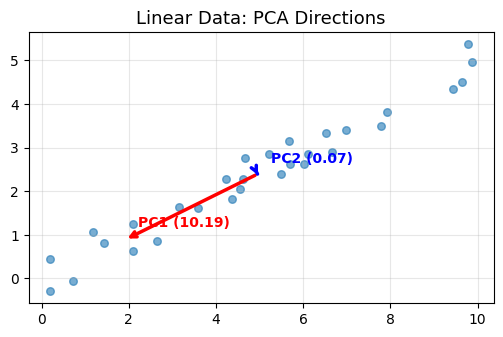


Polynomial KPCA (degree=2) on the same linear data:
  KPCA explained variance: 99.5%, 0.4%
  |Spearman(PC1, KPC1)| = 1.000  (rank correlation; sign is arbitrary)

PC1 captures 99.3% of variance — the data is essentially 1D.
PCA and polynomial KPCA agree on the 1D ordering of points,
so no separate comparison plot is needed on linear data.


In [5]:
np.random.seed(0)
data_1 = np.random.uniform(0, 10, size=(30, 2))
data_1[:, 1] = 0.5 * data_1[:, 0] + np.random.uniform(-0.5, 0.5, 30)

print(f"Data shape: {data_1.shape}")

# PCA
S = cov_matrix(data_1)
print(f"\nCovariance matrix:\n{S.round(3)}")

Z_pca, eigvecs, eigvals, pca_ratios = pca_project(data_1)
print(f"\nPCA eigenvalues: {eigvals.round(4)}")
print(f"Explained variance: {pca_ratios[0]*100:.1f}%, {pca_ratios[1]*100:.1f}%")
print(f"PC1 direction: [{eigvecs[0,0]:.3f}, {eigvecs[1,0]:.3f}]")

plot_pca_vectors(data_1, eigvecs, eigvals, "Linear Data: PCA Directions")
plt.show()

# Verify the claim: on linear data, polynomial KPCA produces the same ranking
# (top component dominates) as PCA. The 1D order of points along PC1 should
# match the 1D order along KPC1 up to sign — Spearman correlation on the
# projected values is a clean way to check this.
Z_kpca_lin, kpca_eigvals_lin, kpca_ratios_lin = kpca_project(
    data_1, poly_kernel, degree=2, coef0=1.0
)
from scipy.stats import spearmanr
rho, _ = spearmanr(Z_pca[:, 0], Z_kpca_lin[:, 0])
print(f"\nPolynomial KPCA (degree=2) on the same linear data:")
print(f"  KPCA explained variance: {kpca_ratios_lin[0]*100:.1f}%, {kpca_ratios_lin[1]*100:.1f}%")
print(f"  |Spearman(PC1, KPC1)| = {abs(rho):.3f}  (rank correlation; sign is arbitrary)")
print(f"\nPC1 captures {pca_ratios[0]*100:.1f}% of variance — the data is essentially 1D.")
print(f"PCA and polynomial KPCA agree on the 1D ordering of points,")
print(f"so no separate comparison plot is needed on linear data.")


---
## Section 3 — Nonlinear Data: PCA Projection Mixes Structures

Three datasets whose class boundaries are inherently nonlinear. Projecting to the PCA direction of maximum variance collapses classes onto the same range.

| Dataset | Structure | Why PCA fails |
|---------|-----------|---------------|
| Concentric Rings | 3 circular clusters | Radial distance carries class info; any line mixes inner and outer |
| Two Moons | 2 interleaving arcs | Variance axis cuts through both classes equally |
| XOR Clusters | 4 anisotropic corners | PC1 aligns with $x_1$; both classes share the same $x_1$ range |

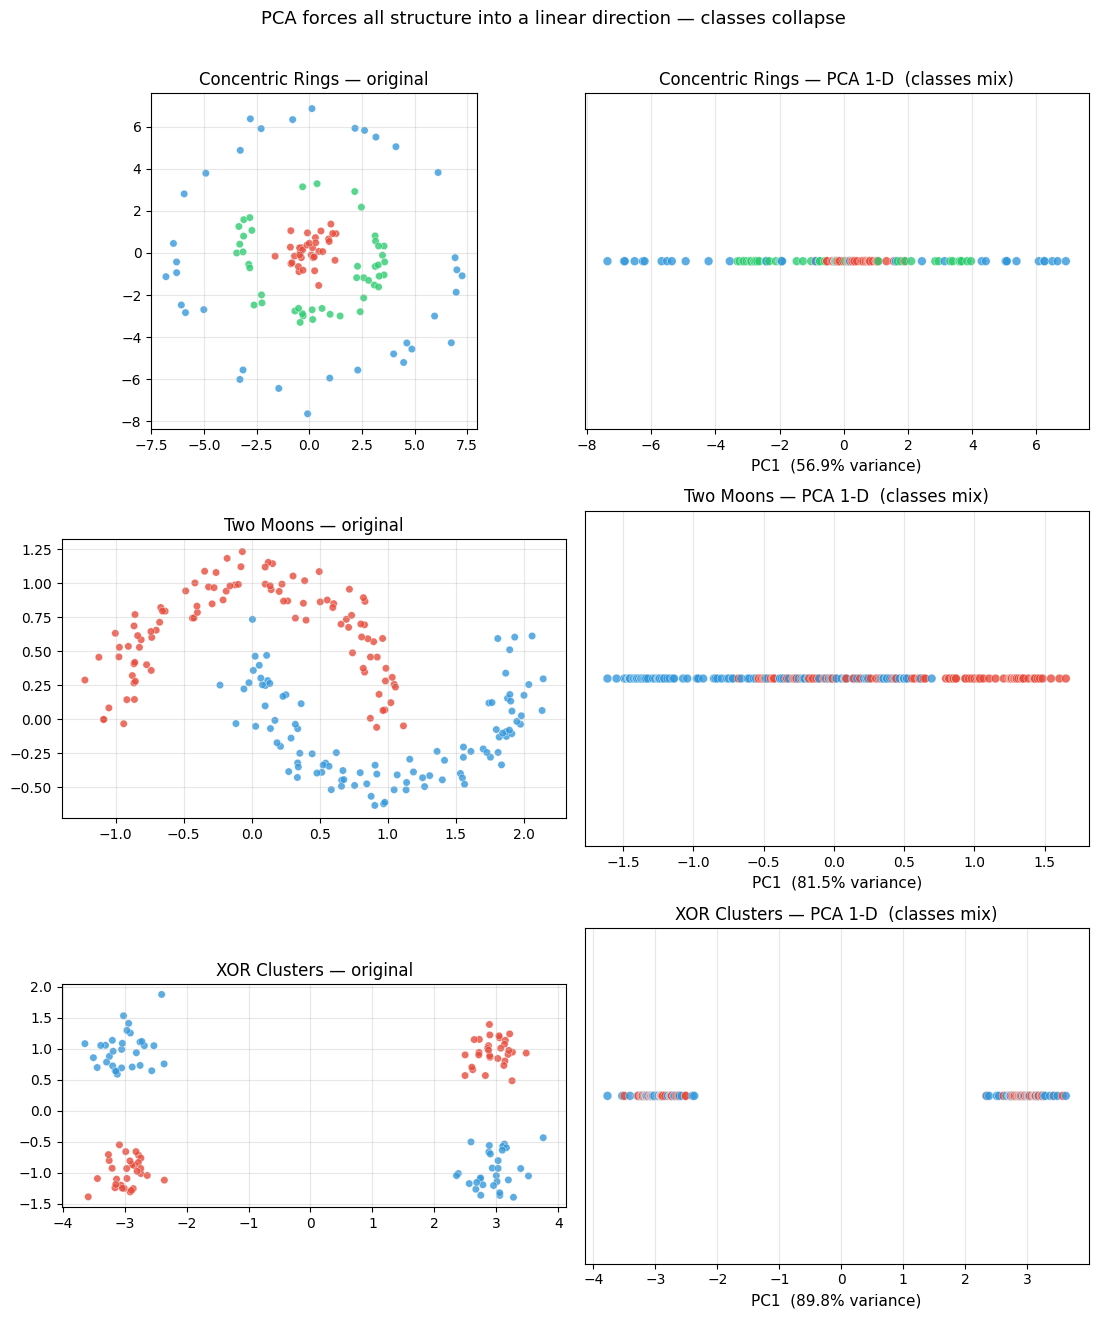

In [6]:
# ── Data generation ──────────────────────────────────────────────────────────

# A: Concentric Rings
rng = np.random.default_rng(0)
n1, n2, n3 = 35, 45, 35
inner = rng.normal(0, 0.7, size=(n1, 2))
theta_mid = rng.uniform(0, 2*np.pi, n2)
r_mid     = rng.normal(3.2, 0.35, n2)
middle = np.c_[r_mid * np.cos(theta_mid), r_mid * np.sin(theta_mid)]
theta_out = rng.uniform(0, 2*np.pi, n3)
r_out     = rng.normal(6.6, 0.45, n3)
outer  = np.c_[r_out * np.cos(theta_out), r_out * np.sin(theta_out)]
data_rings   = np.vstack([inner, middle, outer])
labels_rings = np.array([0]*n1 + [1]*n2 + [2]*n3)
ring_colors  = np.array(['#e74c3c', '#2ecc71', '#3498db'])[labels_rings]

# B: Two Moons
from sklearn.datasets import make_moons
X_moons, y_moons = make_moons(n_samples=200, noise=0.1, random_state=42)
moon_colors = np.array(['#e74c3c', '#3498db'])[y_moons]

# C: XOR Clusters  (anisotropic: var_x1=9, var_x2=1 → PC1 aligns with x1)
rng2 = np.random.default_rng(42)
n_per   = 30
centers = np.array([[-3.0,-1.0],[3.0,1.0],[-3.0,1.0],[3.0,-1.0]])
X_xor   = np.vstack([c + rng2.normal(0, 0.3, size=(n_per, 2)) for c in centers])
y_xor   = np.array([lab for lab in [0,0,1,1] for _ in range(n_per)])
xor_colors = np.array(['#e74c3c', '#3498db'])[y_xor]

# ── PCA failure: original vs 1-D projection ───────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(11, 13))
datasets_pca = [
    ("Concentric Rings", data_rings, ring_colors),
    ("Two Moons",        X_moons,    moon_colors),
    ("XOR Clusters",     X_xor,      xor_colors),
]
for row, (name, X, colors) in enumerate(datasets_pca):
    Z, _, _, ratios = pca_project(X)
    order = np.argsort(Z[:, 0])

    axes[row, 0].scatter(X[:,0], X[:,1], c=colors, s=28, alpha=0.8,
                         edgecolors='white', linewidths=0.3)
    axes[row, 0].set_title(f"{name} — original", fontsize=12)
    axes[row, 0].set_aspect('equal'); axes[row, 0].grid(True, alpha=0.3)

    axes[row, 1].scatter(Z[order, 0], np.zeros(len(Z)),
                         c=np.array(colors)[order], s=40, alpha=0.8,
                         edgecolors='white', linewidths=0.3)
    axes[row, 1].set_xlabel(f"PC1  ({ratios[0]*100:.1f}% variance)", fontsize=11)
    axes[row, 1].set_title(f"{name} — PCA 1-D  (classes mix)", fontsize=12)
    axes[row, 1].set_yticks([]); axes[row, 1].set_ylim(-0.5, 0.5)
    axes[row, 1].grid(True, alpha=0.3)

plt.suptitle("PCA forces all structure into a linear direction — classes collapse",
             fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


---
## Section 4 — KPCA: Re-representing Data with Kernel Similarity

### Why PCA is limited

PCA diagonalises the covariance matrix $S = \frac{1}{N}X^TX$. Every eigenvector is a *linear combination* of the original features. When the meaningful structure lives on a curved manifold, no linear direction can capture it.

### The kernel trick

**Idea:** map data into a high-dimensional feature space $\phi(x)$ where nonlinear structure becomes linearly separable, then run PCA there.

**Problem:** $\phi(x)$ may be infinite-dimensional.

**Solution (kernel trick):** KPCA eigenvectors have the form $v = \sum_i \alpha_i \phi(x_i)$, so every projection reduces to inner products $\phi(x_i)^T\phi(x_j)$. We never compute $\phi$ — only the *kernel function* $\kappa(x_i,x_j)=\phi(x_i)^T\phi(x_j)$.

Build the $n\times n$ Gram matrix, centre it, and eigendecompose:

$$K_{ij}=\kappa(x_i,x_j), \qquad \tilde K = K - \mathbf{1}_n K - K\mathbf{1}_n + \mathbf{1}_n K\mathbf{1}_n$$

Project a new point: $y_m(x)=\sum_i \alpha_i^{(m)}\kappa(x,x_i)$.

### Kernels used in this notebook

| Kernel | Formula | Captures |
|--------|---------|----------|
| **Gaussian (RBF)** | $\exp\!\left(-\dfrac{\|x_i-x_j\|^2}{2\sigma^2}\right)$ | Radial / ring / arc structure |
| **Polynomial** | $(x_i^Tx_j+c)^d$ | Cross-product interactions (e.g.\ $x_1x_2$ for XOR) |

$\sigma$ controls locality: small $\sigma$ → only neighbours are similar; large $\sigma$ → kernel $\approx$ linear → KPCA $\approx$ PCA.

---
## Section 5 — KPCA Projection: Nonlinear Structure Becomes Clearer

Each plot shows the three panels: **original → PCA projection → KPCA projection**. Compare the middle and right panels directly: the classes that collapsed in PCA are now separated by KPCA.

> **Moons caveat:** KPCA components are ordered by *kernel-space variance*, not by class boundary. The moons are clearly separated in 2-D KPCA, but KPCA's *first* component captures radial structure — so at $k=1$ it is *less* discriminative than PCA's linear projection. The classification comparison (Section 6) measures this precisely.

Rings (Gaussian σ=2.0):
  Positive eigenvalues: 100
  Top-2 explained variance: 19.6%, 15.4%


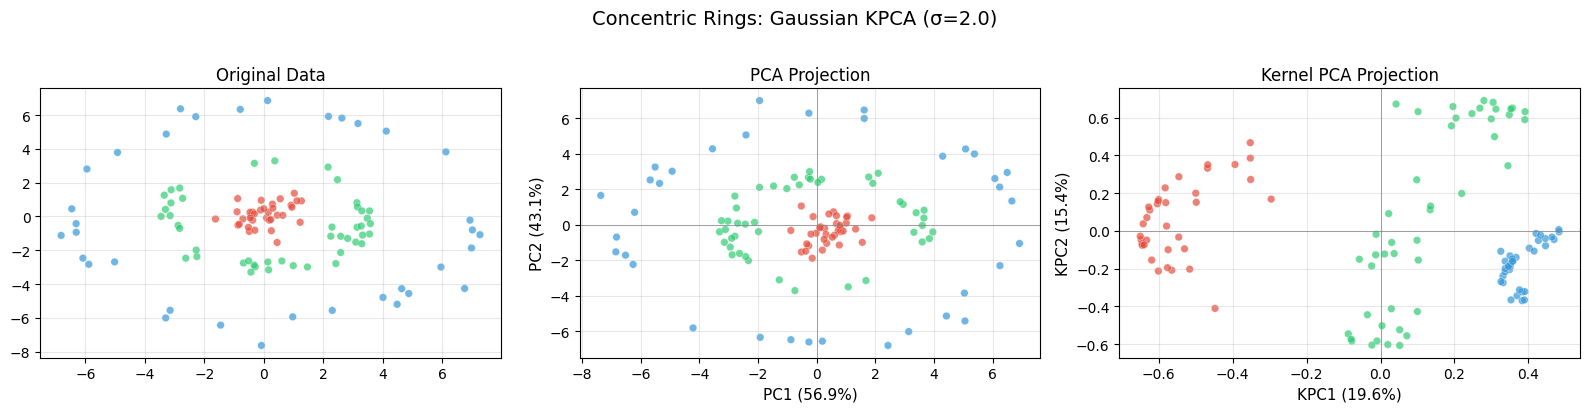


Moons (Gaussian σ=0.5):
  Positive eigenvalues: 126
  Top-2 explained variance: 22.8%, 18.0%


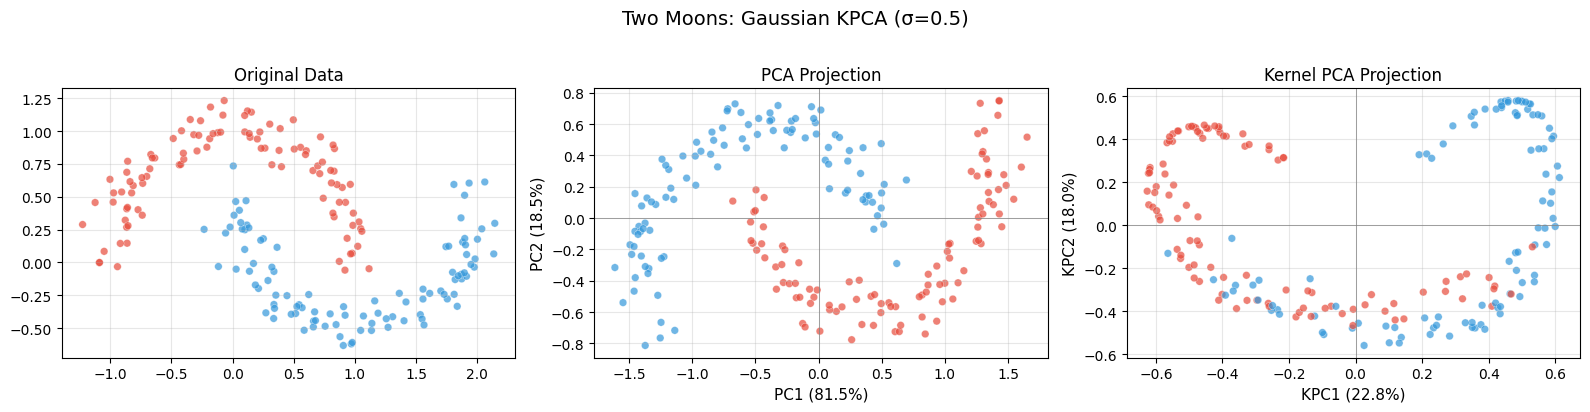


XOR (Polynomial degree=2):
  PCA eigenvalues: [8.95  1.016]  — large gap forces PC1 along x_1
  PC1 direction: [-1.000, -0.001]  (≈ [±1, 0])
  Positive eigenvalues: 5
  Top-2 explained variance: 44.0%, 43.6%


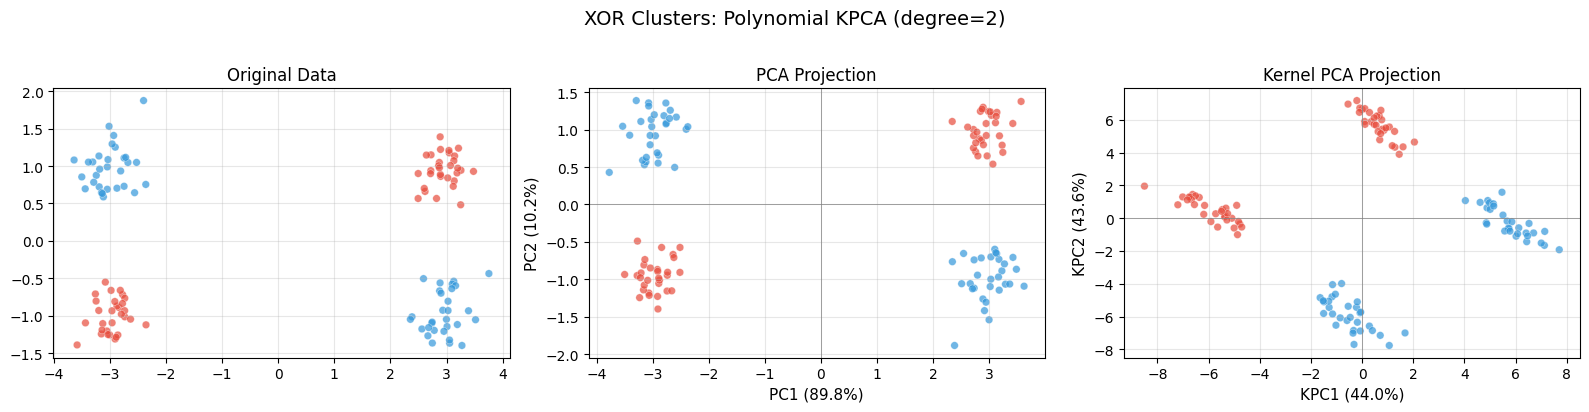

In [7]:
# A: Concentric Rings — Gaussian kernel, σ=2.0
Z_pca_rings, _, _, pca_ratios_rings = pca_project(data_rings)
Z_kpca_rings, kpca_ev_rings, kpca_ratios_rings = kpca_project(
    data_rings, gaussian_kernel, sigma=2.0)
print("Rings (Gaussian σ=2.0):")
print(f"  Positive eigenvalues: {np.sum(kpca_ev_rings > 1e-10)}")
print(f"  Top-2 explained variance: {kpca_ratios_rings[0]*100:.1f}%, {kpca_ratios_rings[1]*100:.1f}%")
plot_comparison(data_rings, Z_pca_rings, Z_kpca_rings,
                pca_ratios_rings, kpca_ratios_rings,
                "Concentric Rings: Gaussian KPCA (σ=2.0)", colors=ring_colors)
plt.show()

# B: Two Moons — Gaussian kernel, σ=0.5
Z_pca_moons, _, _, pca_ratios_moons = pca_project(X_moons)
Z_kpca_moons, kpca_ev_moons, kpca_ratios_moons = kpca_project(
    X_moons, gaussian_kernel, sigma=0.5)
print("\nMoons (Gaussian σ=0.5):")
print(f"  Positive eigenvalues: {np.sum(kpca_ev_moons > 1e-10)}")
print(f"  Top-2 explained variance: {kpca_ratios_moons[0]*100:.1f}%, {kpca_ratios_moons[1]*100:.1f}%")
plot_comparison(X_moons, Z_pca_moons, Z_kpca_moons,
                pca_ratios_moons, kpca_ratios_moons,
                "Two Moons: Gaussian KPCA (σ=0.5)", colors=moon_colors)
plt.show()

# C: XOR Clusters — Polynomial kernel, degree=2
Z_pca_xor, evecs_xor, evals_xor, pca_ratios_xor = pca_project(X_xor)
Z_kpca_xor, kpca_ev_xor, kpca_ratios_xor = kpca_project(
    X_xor, poly_kernel, degree=2, coef0=1.0)
print("\nXOR (Polynomial degree=2):")
print(f"  PCA eigenvalues: {evals_xor.round(3)}  — large gap forces PC1 along x_1")
print(f"  PC1 direction: [{evecs_xor[0,0]:.3f}, {evecs_xor[1,0]:.3f}]  (≈ [±1, 0])")
print(f"  Positive eigenvalues: {np.sum(kpca_ev_xor > 1e-10)}")
print(f"  Top-2 explained variance: {kpca_ratios_xor[0]*100:.1f}%, {kpca_ratios_xor[1]*100:.1f}%")
plot_comparison(X_xor, Z_pca_xor, Z_kpca_xor,
                pca_ratios_xor, kpca_ratios_xor,
                "XOR Clusters: Polynomial KPCA (degree=2)", colors=xor_colors)
plt.show()


---
## Section 6 — Follow-up: Classification and Clustering

With a meaningful low-dimensional representation we can run standard downstream tasks. We show two: **1-NN classification** (supervised) and **K-Means clustering** (unsupervised).

### 6.1 Classification: 1-NN Accuracy vs Number of Components

At $k=1$ both methods compress to one dimension — PCA picks a linear direction, KPCA picks a nonlinear one. At $k=2$, PCA on 2-D data trivially preserves everything. The meaningful comparison is at **$k=1$**.

We sweep $k$ from 1 upward and measure 1-NN accuracy on a 70/30 stratified split.

> **Protocol note:** the numbers here come from a *single* fixed split (`random_state=42`) and are meant as an illustration of the qualitative gap, which is large (tens of points) and stable. For a rigorous protocol — multiple random splits with mean ± std, and $k$ selected on a held-out validation set — see the face-recognition notebook (`pca_kpca_face_recognition.ipynb`), where the PCA–KPCA differences are small enough that this rigor actually matters.

At k=1 (same dimensionality, fair comparison):
  Rings:  PCA 65.7%  vs  KPCA 100.0%  (diff +34.3%)
  Moons:  PCA 80.0%  vs  KPCA 61.7%  (diff -18.3%)
  XOR:    PCA 44.4%  vs  KPCA 100.0%  (diff +55.6%)

At k=2 (PCA preserves all 2D info):
  Rings:  PCA 100.0%  vs  KPCA 100.0%
  Moons:  PCA 100.0%  vs  KPCA 93.3%
  XOR:    PCA 100.0%  vs  KPCA 100.0%
  (Moons k=3: KPCA 100.0%)


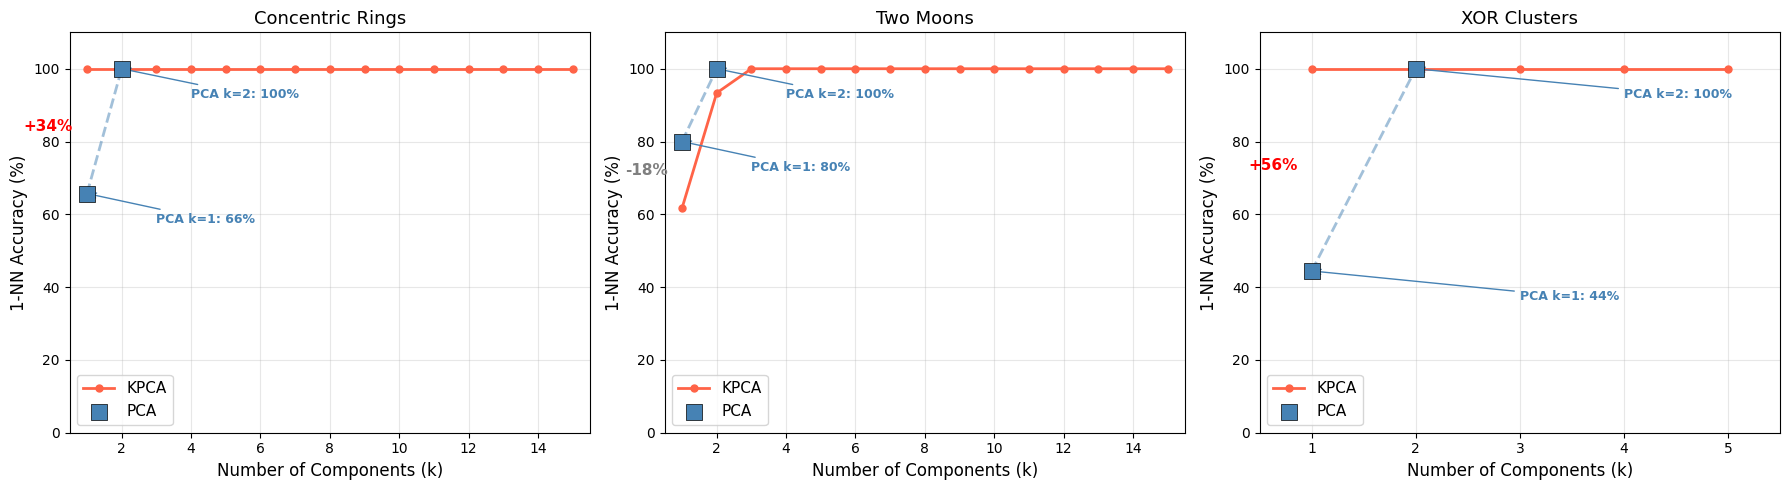


Key insight:
  At k=1, KPCA wins on Rings (+34%) and XOR (+56%) — its single
  nonlinear component captures structure that PCA cannot.
  Moons at k=1 is the exception: KPCA's first component is not
  class-aligned (variance ordering differs from discriminability).
  PCA catches up at k=2 by preserving all 2D info, but this only
  works because the original data is 2D.


In [8]:
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import cdist

def accuracy_vs_k(X, y, kernel_func, max_k=15, **kernel_params):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    N_tr = X_tr.shape[0]

    # PCA: k=1 and k=2
    Xc_tr = X_tr - X_tr.mean(axis=0); Xc_te = X_te - X_tr.mean(axis=0)
    S = np.cov(X_tr, rowvar=False)
    ev, evecs = np.linalg.eigh(S)
    idx = np.argsort(ev)[::-1]; evecs = evecs[:, idx]

    pca_accs = []
    for k in [1, 2]:
        W = evecs[:, :k]
        dists = cdist(Xc_te @ W, Xc_tr @ W)
        pca_accs.append(np.mean(y_tr[np.argmin(dists, axis=1)] == y_te) * 100)

    # KPCA: k=1 to max_k
    K_tr = kernel_func(X_tr, X_tr, **kernel_params)
    Kc_tr = center_kernel(K_tr)
    ev_k, evec_k = np.linalg.eigh(Kc_tr)
    idx_k = np.argsort(ev_k)[::-1]; ev_k = ev_k[idx_k]; evec_k = evec_k[:, idx_k]
    pos = ev_k > 1e-10; ev_k = ev_k[pos]; evec_k = evec_k[:, pos]
    alpha = evec_k / np.sqrt(ev_k)
    Z_tr = Kc_tr @ alpha

    one_N = np.ones((N_tr, N_tr)) / N_tr
    K_te = kernel_func(X_te, X_tr, **kernel_params)
    N_te = X_te.shape[0]; one_te = np.ones((N_te, N_tr)) / N_tr
    Kc_te = K_te - one_te @ K_tr - K_te @ one_N + one_te @ K_tr @ one_N
    Z_te = Kc_te @ alpha

    kpca_accs = []
    actual_max = min(max_k, Z_tr.shape[1])
    for k in range(1, actual_max + 1):
        dists = cdist(Z_te[:, :k], Z_tr[:, :k])
        kpca_accs.append(np.mean(y_tr[np.argmin(dists, axis=1)] == y_te) * 100)

    return pca_accs, kpca_accs

# Run on all three nonlinear datasets
pca_r, kpca_r = accuracy_vs_k(data_rings, labels_rings, gaussian_kernel, sigma=2.0)
pca_m, kpca_m = accuracy_vs_k(X_moons, y_moons, gaussian_kernel, sigma=0.5)
pca_x, kpca_x = accuracy_vs_k(X_xor, y_xor, poly_kernel, degree=2, coef0=1.0)

# Print key comparison at k=1
print("At k=1 (same dimensionality, fair comparison):")
print(f"  Rings:  PCA {pca_r[0]:.1f}%  vs  KPCA {kpca_r[0]:.1f}%  (diff {kpca_r[0]-pca_r[0]:+.1f}%)")
print(f"  Moons:  PCA {pca_m[0]:.1f}%  vs  KPCA {kpca_m[0]:.1f}%  (diff {kpca_m[0]-pca_m[0]:+.1f}%)")
print(f"  XOR:    PCA {pca_x[0]:.1f}%  vs  KPCA {kpca_x[0]:.1f}%  (diff {kpca_x[0]-pca_x[0]:+.1f}%)")
print(f"\nAt k=2 (PCA preserves all 2D info):")
print(f"  Rings:  PCA {pca_r[1]:.1f}%  vs  KPCA {kpca_r[1]:.1f}%")
print(f"  Moons:  PCA {pca_m[1]:.1f}%  vs  KPCA {kpca_m[1]:.1f}%")
print(f"  XOR:    PCA {pca_x[1]:.1f}%  vs  KPCA {kpca_x[1]:.1f}%")
print(f"  (Moons k=3: KPCA {kpca_m[2]:.1f}%)")

# Plot: accuracy vs k (three subplots)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (title, pca_a, kpca_a) in zip(axes, [
    ('Concentric Rings', pca_r, kpca_r),
    ('Two Moons', pca_m, kpca_m),
    ('XOR Clusters', pca_x, kpca_x),
]):
    k_kpca = list(range(1, len(kpca_a)+1))

    # KPCA curve
    ax.plot(k_kpca, kpca_a, 'o-', color='tomato', markersize=5, linewidth=2, label='KPCA')

    # PCA: k=1 and k=2 as horizontal markers
    ax.scatter([1], [pca_a[0]], c='steelblue', s=120, zorder=5, marker='s', edgecolors='black', linewidths=0.5)
    ax.scatter([2], [pca_a[1]], c='steelblue', s=120, zorder=5, marker='s', edgecolors='black', linewidths=0.5)
    ax.plot([1, 2], pca_a, 's--', color='steelblue', markersize=0, linewidth=2, alpha=0.5)
    ax.annotate(f'PCA k=1: {pca_a[0]:.0f}%', xy=(1, pca_a[0]), xytext=(3, pca_a[0]-8),
                fontsize=9, color='steelblue', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='steelblue', lw=1))
    ax.annotate(f'PCA k=2: {pca_a[1]:.0f}%', xy=(2, pca_a[1]), xytext=(4, pca_a[1]-8),
                fontsize=9, color='steelblue', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='steelblue', lw=1))

    # Highlight k=1 comparison
    diff1 = kpca_a[0] - pca_a[0]
    if diff1 > 0:
        ax.annotate(f'+{diff1:.0f}%', xy=(1, (kpca_a[0]+pca_a[0])/2),
                    fontsize=11, color='red', fontweight='bold', ha='right',
                    xytext=(-10, 0), textcoords='offset points')
    elif diff1 < 0:
        ax.annotate(f'{diff1:.0f}%', xy=(1, (kpca_a[0]+pca_a[0])/2),
                    fontsize=11, color='gray', fontweight='bold', ha='right',
                    xytext=(-10, 0), textcoords='offset points')

    ax.set_xlabel('Number of Components (k)', fontsize=12)
    ax.set_ylabel('1-NN Accuracy (%)', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(['KPCA', 'PCA'], fontsize=11)
    ax.set_ylim(0, 110)
    ax.set_xlim(0.5, len(kpca_a)+0.5)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nKey insight:")
print(f"  At k=1, KPCA wins on Rings (+34%) and XOR (+56%) — its single")
print(f"  nonlinear component captures structure that PCA cannot.")
print(f"  Moons at k=1 is the exception: KPCA's first component is not")
print(f"  class-aligned (variance ordering differs from discriminability).")
print(f"  PCA catches up at k=2 by preserving all 2D info, but this only")
print(f"  works because the original data is 2D.")


### 6.2 Clustering: K-Means on PCA vs KPCA Projections

K-Means assumes **spherical, linearly separable clusters**. On PCA projections of nonlinear data those assumptions fail badly. On KPCA projections the geometry improves — dramatically when the kernel encodes exactly the right structure (XOR), partially otherwise (Rings, Moons).

**Adjusted Rand Index (ARI):** 1.0 = perfect match with ground truth, 0 = random assignment. Points are plotted in the original 2-D space, coloured by cluster assignment.

Concentric Rings      PCA ARI = 0.13   KPCA ARI = 0.55   diff = +0.42
Two Moons             PCA ARI = 0.22   KPCA ARI = 0.38   diff = +0.16
XOR Clusters          PCA ARI = -0.01   KPCA ARI = 1.00   diff = +1.01


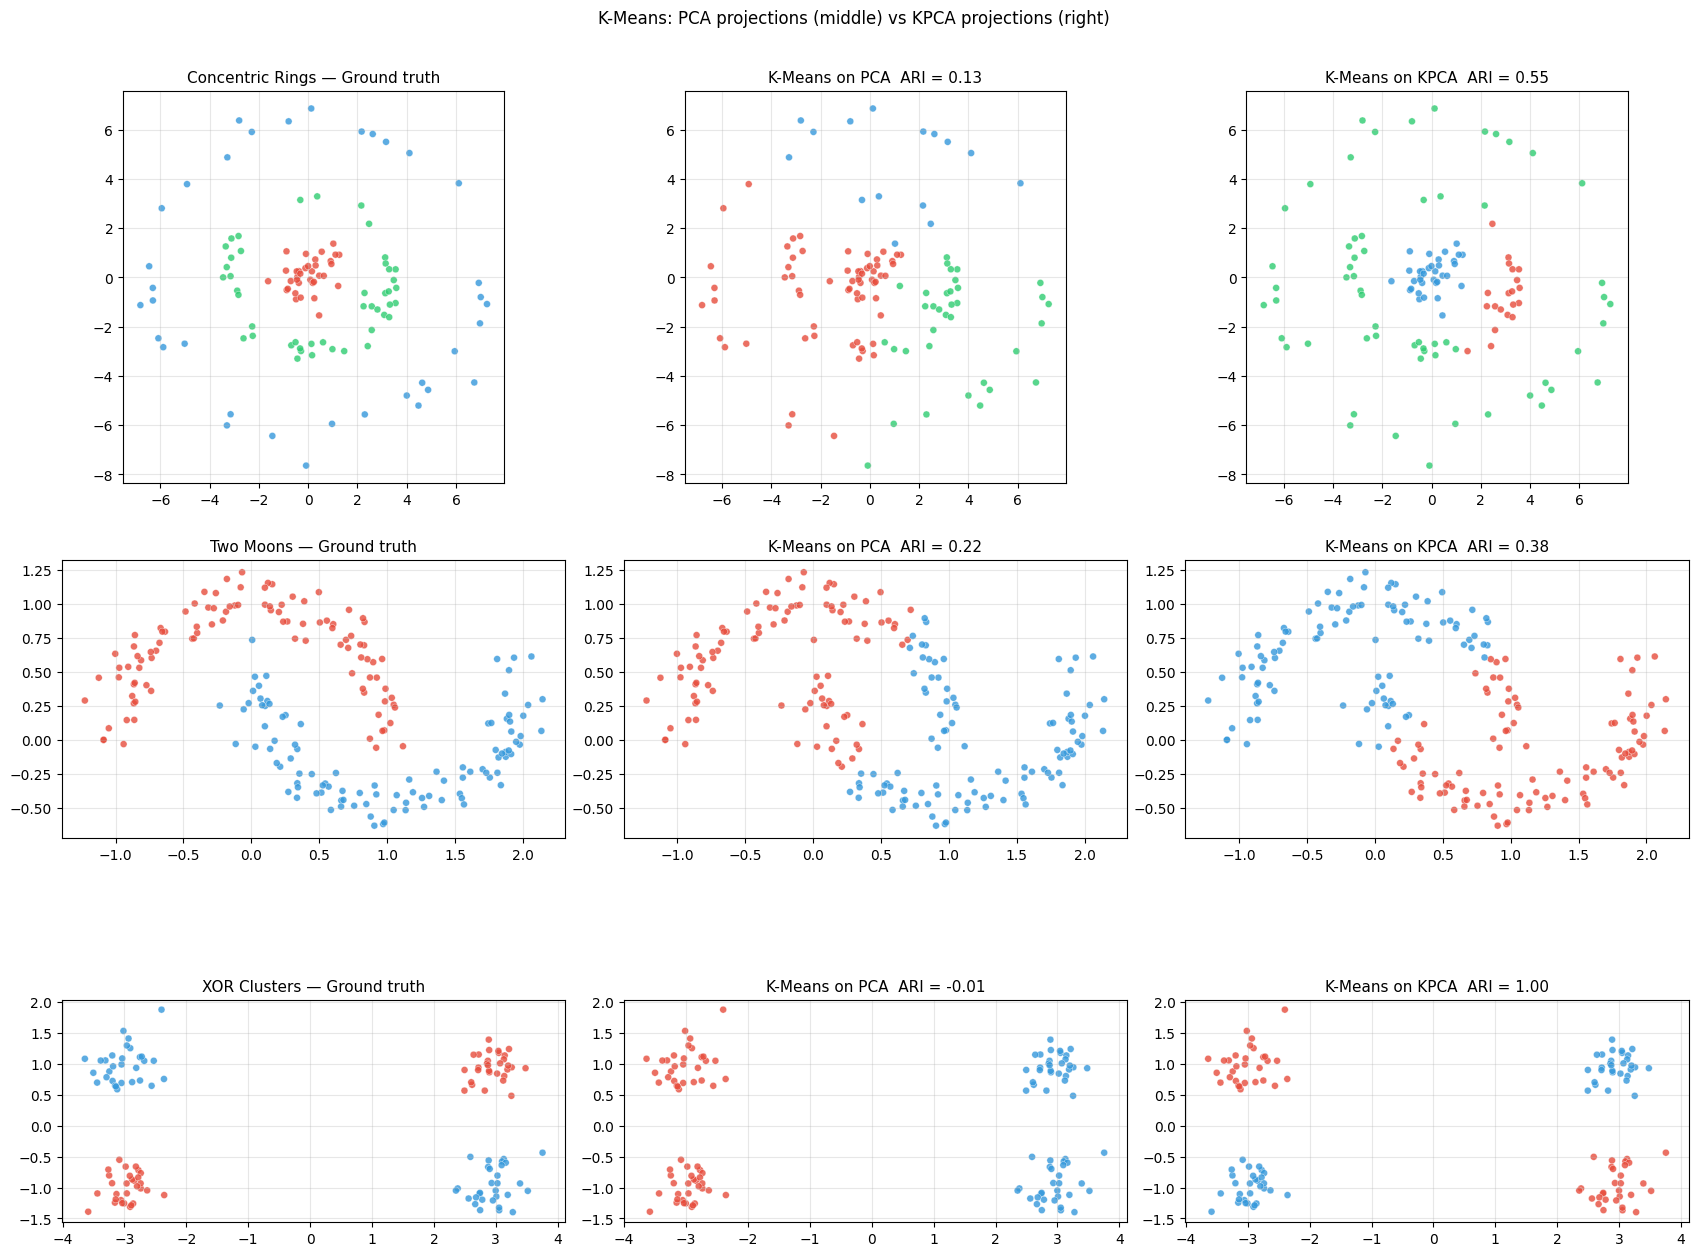


Reading the numbers honestly:
  XOR:   KPCA solves it outright (ARI 1.00) — the kernel encodes exactly
         the right invariant (x1*x2), so clusters become convex in 1-D.
  Rings / Moons: KPCA improves K-Means a lot over PCA, but does not fully
         solve them. Plain (unnormalised) KPCA + K-Means is weaker than
         spectral clustering, which adds affinity normalisation on top of
         the same eigen-machinery. The gap is structural, not a tuning issue.


In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# Kernel choice for clustering:
#  - Rings / Moons reuse the Section-5 kernels (sigma=2.0 / sigma=0.5).
#  - XOR uses the HOMOGENEOUS quadratic kernel (coef0=0). With coef0=1 the
#    feature map contains a linear x1 term whose large variance (var_x1=9)
#    leaks into KPC1, so the two classes overlap along it and K-Means cuts
#    the wrong way (ARI ~ 0.25). Dropping the constant term removes the
#    linear features entirely; KPC1 then aligns with the discriminative
#    cross-term x1*x2 and 1-D K-Means recovers the classes exactly.
#    (1-NN classification is insensitive to this because the four blobs stay
#    tight under either kernel — but K-Means geometry is not.)
datasets_cluster = [
    ("Concentric Rings", data_rings, labels_rings, ring_colors, 3,
     gaussian_kernel, dict(sigma=2.0), 2),
    ("Two Moons",        X_moons,    y_moons,       moon_colors, 2,
     gaussian_kernel, dict(sigma=0.5), 2),
    ("XOR Clusters",     X_xor,      y_xor,         xor_colors,  2,
     poly_kernel,     dict(degree=2, coef0=0.0), 1),
]
pal3 = ['#e74c3c', '#2ecc71', '#3498db']
pal2 = ['#e74c3c', '#3498db']

fig, axes = plt.subplots(3, 3, figsize=(17, 13))

for row, (name, X, y_true, true_colors, n_cl, kfunc, kparams, n_kpca) in enumerate(datasets_cluster):
    pal = pal3 if n_cl == 3 else pal2

    # Ground truth
    axes[row,0].scatter(X[:,0], X[:,1], c=true_colors, s=25, alpha=0.8,
                        edgecolors='white', linewidths=0.3)
    axes[row,0].set_title(name + " — Ground truth", fontsize=11)
    axes[row,0].set_aspect('equal'); axes[row,0].grid(True, alpha=0.3)

    # K-Means on PCA
    Z_p, _, _, _ = pca_project(X)
    km_p  = KMeans(n_clusters=n_cl, random_state=0, n_init=10).fit(Z_p)
    ari_p = adjusted_rand_score(y_true, km_p.labels_)
    axes[row,1].scatter(X[:,0], X[:,1], c=np.array(pal)[km_p.labels_],
                        s=25, alpha=0.8, edgecolors='white', linewidths=0.3)
    axes[row,1].set_title("K-Means on PCA  ARI = " + f"{ari_p:.2f}", fontsize=11)
    axes[row,1].set_aspect('equal'); axes[row,1].grid(True, alpha=0.3)

    # K-Means on KPCA (n_kpca components)
    Z_k, _, _ = kpca_project(X, kfunc, n_components=n_kpca, **kparams)
    km_k  = KMeans(n_clusters=n_cl, random_state=0, n_init=10).fit(Z_k)
    ari_k = adjusted_rand_score(y_true, km_k.labels_)
    axes[row,2].scatter(X[:,0], X[:,1], c=np.array(pal)[km_k.labels_],
                        s=25, alpha=0.8, edgecolors='white', linewidths=0.3)
    axes[row,2].set_title("K-Means on KPCA  ARI = " + f"{ari_k:.2f}", fontsize=11)
    axes[row,2].set_aspect('equal'); axes[row,2].grid(True, alpha=0.3)

    print(f"{name:20s}  PCA ARI = {ari_p:.2f}   KPCA ARI = {ari_k:.2f}   diff = {ari_k-ari_p:+.2f}")

plt.suptitle("K-Means: PCA projections (middle) vs KPCA projections (right)",
             fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

print("\nReading the numbers honestly:")
print("  XOR:   KPCA solves it outright (ARI 1.00) — the kernel encodes exactly")
print("         the right invariant (x1*x2), so clusters become convex in 1-D.")
print("  Rings / Moons: KPCA improves K-Means a lot over PCA, but does not fully")
print("         solve them. Plain (unnormalised) KPCA + K-Means is weaker than")
print("         spectral clustering, which adds affinity normalisation on top of")
print("         the same eigen-machinery. The gap is structural, not a tuning issue.")


---
## Summary

| Dataset | Kernel | PCA $k=1$ | KPCA $k=1$ | Clustering (ARI, PCA → KPCA) |
|---------|--------|-----------|-----------|------------------------------|
| Linear | — | — | — (same) | N/A |
| Concentric Rings | Gaussian $\sigma=2$ | 66% | **100%** | 0.13 → 0.55 |
| Two Moons | Gaussian $\sigma=0.5$ | 80% | 62%\* | 0.22 → 0.38 |
| XOR Clusters | Polynomial $d=2$ | 44% | **100%** | −0.01 → **1.00**† |

\*KPCA's first component orders by kernel-space variance, not class boundary. Accuracy recovers as more components are added — 93% at $k=2$, 100% from $k=3$ — see Section 6.1.

†Clustering uses the homogeneous quadratic kernel ($c=0$); see the note in Section 6.2 for why the constant term matters there.

(Classification accuracies from a single 70/30 split; see the protocol note in Section 6.1.)

**Key takeaways:**

1. **Kernel choice matters — down to the constant term.** Gaussian captures radial/arc structure; polynomial captures cross-product interactions. On XOR, merely switching the polynomial kernel from $c=1$ to $c=0$ takes K-Means from ARI 0.25 to 1.00, because it removes linear features that drown out the discriminative $x_1x_2$ term.
2. **KPCA variance ≠ discriminability.** The first KPCA component maximises variance in feature space, not classification accuracy (Two Moons example).
3. **KPCA helps K-Means, but only fully solves clustering when the kernel matches the structure exactly.** XOR becomes perfectly clusterable (ARI 1.00); Rings and Moons improve substantially over PCA (0.13→0.55, 0.22→0.38) yet remain unsolved — plain KPCA + K-Means lacks the affinity normalisation that makes spectral clustering succeed on such data.
4. **On linear data, KPCA = PCA.** No kernel adds value when the structure is already linear.